# RealEstate End-to-End Pipeline Notebook

**Complete Machine Learning Pipeline for Tunisian Real Estate Price Prediction**

This notebook contains the full implementation of all 8 pipeline stages, from raw data discovery to trained model deployment.

---

## Table of Contents

1. [Project Overview](#1)
2. [Environment Setup](#2)
3. [Utility Functions](#3)
4. [Data Sources](#4)
5. [Stage 1: Dataset Discovery](#5)
6. [Stage 2: Dataset Cleaning](#6)
7. [Stage 3: Merge Preparation](#7)
8. [Stage 4: Geographic Alignment](#8)
9. [Stage 5: Training Dataset Preparation](#9)
10. [Stage 6: Feature Engineering](#10)
11. [Stage 7: Visual Check](#11)
12. [Stage 8: Model Training](#12)
13. [Conclusion](#13)

---

<a id='1'></a>
## 1. Project Overview

### Objective

Build a machine learning model to predict real estate prices in Tunisia by:
- Processing 3 raw datasets from different sources
- Cleaning and standardizing property listings
- Aligning location names with official geographic boundaries
- Engineering predictive features
- Training and comparing ensemble models

### Pipeline Architecture

The pipeline consists of 8 sequential stages:

| Stage | Name | Purpose |
|-------|------|---------|
| 01 | Dataset Discovery | Profile raw datasets, identify quality issues |
| 02 | Dataset Cleaning | Standardize schemas, fix encodings, remove invalid records |
| 03 | Merge Preparation | Combine datasets, deduplicate cross-source records |
| 04 | Geographic Alignment | Match location names to official boundaries |
| 05 | Training Dataset Preparation | Filter and prepare model-ready data |
| 06 | Feature Engineering | Add derived features (coordinates, encodings) |
| 07 | Visual Check | Sample and validate final dataset |
| 08 | Model Training | Train models, select best, generate predictions |

### Stage Order Note

The production notebook and exported HTML are synchronized so that the later workflow chapters now follow this exact order without cross-stage mixing: **Stage 04 Geographic Alignment -> Stage 05 Training Dataset Preparation -> Stage 06 Feature Engineering -> Stage 07 Visual Check -> Stage 08 Model Training**.

### Key Outputs

- Training dataset: `data/processed/05_training_dataset/05_training_dataset.csv`
- Feature dataset: `data/processed/06_feature_engineering/06_feature_engineered_dataset.csv`
- Trained model: `artifacts/08_best_model.joblib`
- Model report: `data/processed/08_model_training/08_model_training_report.json`
- Frontend summary: `frontend/model_summary.json`
- Frontend asset manifest: `frontend/assets/data/pipeline_assets_manifest.json`

<a id='2'></a>
## 2. Environment Setup

### Libraries

- **pandas** & **numpy**: Data manipulation
- **scikit-learn**: ML models and preprocessing
- **joblib**: Model serialization
- **json**: Reports and configuration

### Generated Frontend Asset Bundle

The production pipeline also exports frontend-facing assets after model training so the atlas and notebook stay synchronized with the latest run:

- `frontend/assets/data/atlas.geojson`
- `frontend/assets/data/zone_coverage.json`
- `frontend/assets/data/delegation_profiles.json`
- `frontend/assets/data/pipeline_assets_manifest.json`
- `frontend/model_summary.json`

These files are generated from the real pipeline outputs and should be treated as deployment assets, not hand-edited artifacts.

In [1]:
# Import libraries
from __future__ import annotations
import json, re, unicodedata
from pathlib import Path
from typing import Any
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None)
print("✓ Libraries imported")


✓ Libraries imported


In [2]:
# Configure paths
PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
GEO_DIR = PROJECT_ROOT / "geo"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

# Stage directories
DISCOVERY_DIR = PROCESSED_DIR / "01_discovery"
CLEANING_DIR = PROCESSED_DIR / "02_cleaning"
MERGE_DIR = PROCESSED_DIR / "03_merge"
GEO_ALIGNMENT_DIR = PROCESSED_DIR / "04_geo_alignment"
TRAINING_DATASET_DIR = PROCESSED_DIR / "05_training_dataset"
FEATURE_ENGINEERING_DIR = PROCESSED_DIR / "06_feature_engineering"
VISUAL_CHECK_DIR = PROCESSED_DIR / "07_visual_check"
MODEL_TRAINING_DIR = PROCESSED_DIR / "08_model_training"

# Create directories
for d in [PROCESSED_DIR, DISCOVERY_DIR, CLEANING_DIR, MERGE_DIR, GEO_ALIGNMENT_DIR,
          TRAINING_DATASET_DIR, FEATURE_ENGINEERING_DIR, VISUAL_CHECK_DIR, 
          MODEL_TRAINING_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print(f"✓ Paths configured (root: {PROJECT_ROOT})")


✓ Paths configured (root: c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2)


<a id='3'></a>
## 3. Utility Functions

These helper functions are used throughout the pipeline for:
- Reading CSVs with multiple encoding attempts
- Text normalization and repair
- JSON serialization
- Data validation

In [3]:
# CSV reading with encoding fallback
def read_csv_any(path: Path) -> pd.DataFrame:
    """Try multiple encodings to read CSV."""
    for encoding in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=encoding, on_bad_lines="skip", engine="python")
        except Exception:
            continue
    raise RuntimeError(f"Unable to read {path}")

print("✓ read_csv_any defined")


✓ read_csv_any defined


### Why These Utility Functions?

The raw datasets have inconsistent encodings (UTF-8, Latin-1, Windows-1252) and messy text formatting. These utilities handle:
- **Encoding detection**: Try multiple encodings until one works
- **Text repair**: Fix mojibake and encoding corruption
- **Normalization**: Convert to consistent lowercase, remove accents
- **Type conversion**: Parse numbers from various string formats

These functions are used throughout all pipeline stages.

In [4]:
# Text repair and normalization
def repair_text(value: Any) -> str:
    """Fix encoding issues and normalize whitespace."""
    if value is None or pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    # Fix common encoding issues
    if any(token in text for token in ("Ã", "Â", "â", "�")):
        for enc in ("latin-1", "cp1252"):
            try:
                text = text.encode(enc).decode("utf-8")
                break
            except:
                continue
    return re.sub(r"\s+", " ", text.replace("\xa0", " ")).strip()

def normalize_text(value: Any) -> str:
    """Normalize to lowercase, remove accents, keep alphanumeric."""
    text = repair_text(value).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

print("✓ Text functions defined")


✓ Text functions defined


In [5]:
# JSON serialization
def make_json_safe(value: Any) -> Any:
    """Convert numpy/pandas types to JSON-serializable types."""
    if isinstance(value, dict):
        return {str(k): make_json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_json_safe(v) for v in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    if pd.isna(value):
        return None
    return value

def write_json(path: Path, payload: dict) -> None:
    """Write JSON with proper encoding."""
    path.write_text(json.dumps(make_json_safe(payload), indent=2, ensure_ascii=False), encoding="utf-8")

print("✓ JSON functions defined")


✓ JSON functions defined


In [6]:
# Numeric parsing
def parse_float(value: Any) -> float | None:
    """Parse float from various formats."""
    if value is None or pd.isna(value):
        return None
    if isinstance(value, (int, float)) and not pd.isna(value):
        return float(value)
    text = repair_text(value).replace("TND", "").replace("DT", "").replace("€", "").replace(",", ".")
    matches = re.findall(r"-?\d+(?:\.\d+)?", text)
    return float(matches[0]) if matches else None

def parse_int(value: Any) -> int | None:
    """Parse integer from various formats."""
    numeric = parse_float(value)
    return int(round(numeric)) if numeric is not None else None

print("✓ Numeric parsing functions defined")


✓ Numeric parsing functions defined


<a id='4'></a>
## 4. Data Sources

### Input Datasets

The pipeline processes three raw CSV files:

1. **tunisia-real-estate.csv** - Primary structured listings
2. **Property Prices in Tunisia.csv** - Secondary marketplace listings  
3. **data_prices_cleaned.csv** - Pre-cleaned marketplace data

### Geographic Reference Files

- **delegations-full.geojson** - Official administrative boundaries
- **tunisia.json** - Locality-to-delegation mappings

### Dataset Manifest

### About the Input Data

We're working with **3 different real estate listing sources**, each with its own schema and quirks:
- Different column names for the same concepts
- Different encodings and text formats
- Mix of sale/rental listings (we only want sales)
- Inconsistent location naming

The pipeline will standardize all three into one unified format.

In [7]:
# Define input datasets
DATASETS = {
    "tunisia_real_estate": RAW_DIR / "tunisia-real-estate.csv",
    "property_prices_in_tunisia": RAW_DIR / "Property Prices in Tunisia.csv",
    "data_prices_cleaned": RAW_DIR / "data_prices_cleaned.csv",
}

# Check files exist
for name, path in DATASETS.items():
    exists = "✓" if path.exists() else "✗"
    print(f"{exists} {name}: {path.name}")


✓ tunisia_real_estate: tunisia-real-estate.csv
✓ property_prices_in_tunisia: Property Prices in Tunisia.csv
✓ data_prices_cleaned: data_prices_cleaned.csv


<a id='5'></a>
## 5. Stage 1: Dataset Discovery

### Purpose

Profile each raw dataset to understand:
- Row and column counts
- Data types and missing values
- Price and surface distributions
- Location value frequencies
- Dataset-specific issues

### Process

1. Load each dataset with encoding fallback
2. Identify price, surface, and location columns
3. Calculate statistics and distributions
4. Detect empty columns and duplicates
5. Generate discovery reports

### What Discovery Reveals

Before cleaning, we need to understand what we're working with. Discovery will show us:
- How many rows and columns each dataset has
- Which columns contain price, surface, and location data
- How many missing values and duplicates exist
- Dataset-specific issues (negative values, placeholder data, etc.)

This information guides our cleaning strategy.

In [8]:
# Column candidates for auto-detection
PRICE_COLUMN_CANDIDATES = ["price", "Price"]
SURFACE_COLUMN_CANDIDATES = ["size", "superficie", "Surface"]
LOCATION_COLUMN_CANDIDATES = ["city", "City", "region", "Region", "location", "Locality", "Delegation", "Governorate"]

def find_first_column(frame: pd.DataFrame, candidates: list[str]) -> str | None:
    """Find first matching column name."""
    for name in candidates:
        if name in frame.columns:
            return name
    return None

print("✓ Column detection functions defined")


✓ Column detection functions defined


In [9]:
# Profile a single dataset
def profile_dataset(name: str, path: Path) -> dict:
    """Generate comprehensive dataset profile."""
    frame = read_csv_any(path)
    
    # Detect key columns
    price_col = find_first_column(frame, PRICE_COLUMN_CANDIDATES)
    surface_col = find_first_column(frame, SURFACE_COLUMN_CANDIDATES)
    location_col = find_first_column(frame, LOCATION_COLUMN_CANDIDATES)
    
    # Convert to numeric
    price_series = pd.to_numeric(frame[price_col], errors="coerce") if price_col else pd.Series(dtype=float)
    surface_series = pd.to_numeric(frame[surface_col], errors="coerce") if surface_col else pd.Series(dtype=float)
    
    # Detect empty columns
    all_empty_columns = []
    for col in frame.columns:
        if frame[col].isna().all() or (frame[col].dtype == object and frame[col].fillna("").astype(str).str.strip().eq("").all()):
            all_empty_columns.append(col)
    
    profile = {
        "dataset_name": name,
        "file_name": path.name,
        "rows": int(len(frame)),
        "columns": list(frame.columns),
        "column_count": int(len(frame.columns)),
        "all_empty_columns": all_empty_columns,
        "duplicate_rows_exact": int(frame.duplicated().sum()),
        "price_column": price_col,
        "surface_column": surface_col,
        "location_column": location_col,
        "price_missing": int(price_series.isna().sum()) if not price_series.empty else None,
        "surface_missing": int(surface_series.isna().sum()) if not surface_series.empty else None,
        "price_non_positive": int(price_series.le(0).sum()) if not price_series.empty else None,
        "surface_non_positive": int(surface_series.le(0).sum()) if not surface_series.empty else None,
    }
    return profile

print("✓ profile_dataset function defined")


✓ profile_dataset function defined


### Visualization: Dataset Overview

Let's visualize the key characteristics of our three raw datasets.

In [10]:
# Run discovery on all datasets
print("Running dataset discovery...\n")

profiles = []
for dataset_name, path in DATASETS.items():
    print(f"Profiling {dataset_name}...")
    profile = profile_dataset(dataset_name, path)
    profiles.append(profile)
    output_path = DISCOVERY_DIR / f"01_{dataset_name}_discovery.json"
    write_json(output_path, profile)
    print(f"  Rows: {profile['rows']:,}")
    print(f"  Columns: {profile['column_count']}")
    print(f"  Empty columns: {len(profile['all_empty_columns'])}")
    print(f"  Duplicates: {profile['duplicate_rows_exact']:,}")
    print()

print(f"✓ Discovery complete. Profiles saved to {DISCOVERY_DIR}")


Running dataset discovery...

Profiling tunisia_real_estate...
  Rows: 25,317
  Columns: 8
  Empty columns: 0
  Duplicates: 0

Profiling property_prices_in_tunisia...
  Rows: 12,748
  Columns: 9
  Empty columns: 0
  Duplicates: 1,613

Profiling data_prices_cleaned...
  Rows: 8,336
  Columns: 17
  Empty columns: 0
  Duplicates: 0

✓ Discovery complete. Profiles saved to c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\01_discovery


In [11]:
# Display discovery summary
summary_df = pd.DataFrame([
    {
        "Dataset": p["dataset_name"],
        "Rows": p["rows"],
        "Columns": p["column_count"],
        "Empty Cols": len(p["all_empty_columns"]),
        "Duplicates": p["duplicate_rows_exact"],
        "Price Missing": p["price_missing"],
        "Surface Missing": p["surface_missing"],
    }
    for p in profiles
])

print("\n=== Dataset Discovery Summary ===")
print(summary_df.to_string(index=False))



=== Dataset Discovery Summary ===
                   Dataset  Rows  Columns  Empty Cols  Duplicates  Price Missing  Surface Missing
       tunisia_real_estate 25317        8           0           0              0                0
property_prices_in_tunisia 12748        9           0        1613              0                0
       data_prices_cleaned  8336       17           0           0             14             1584


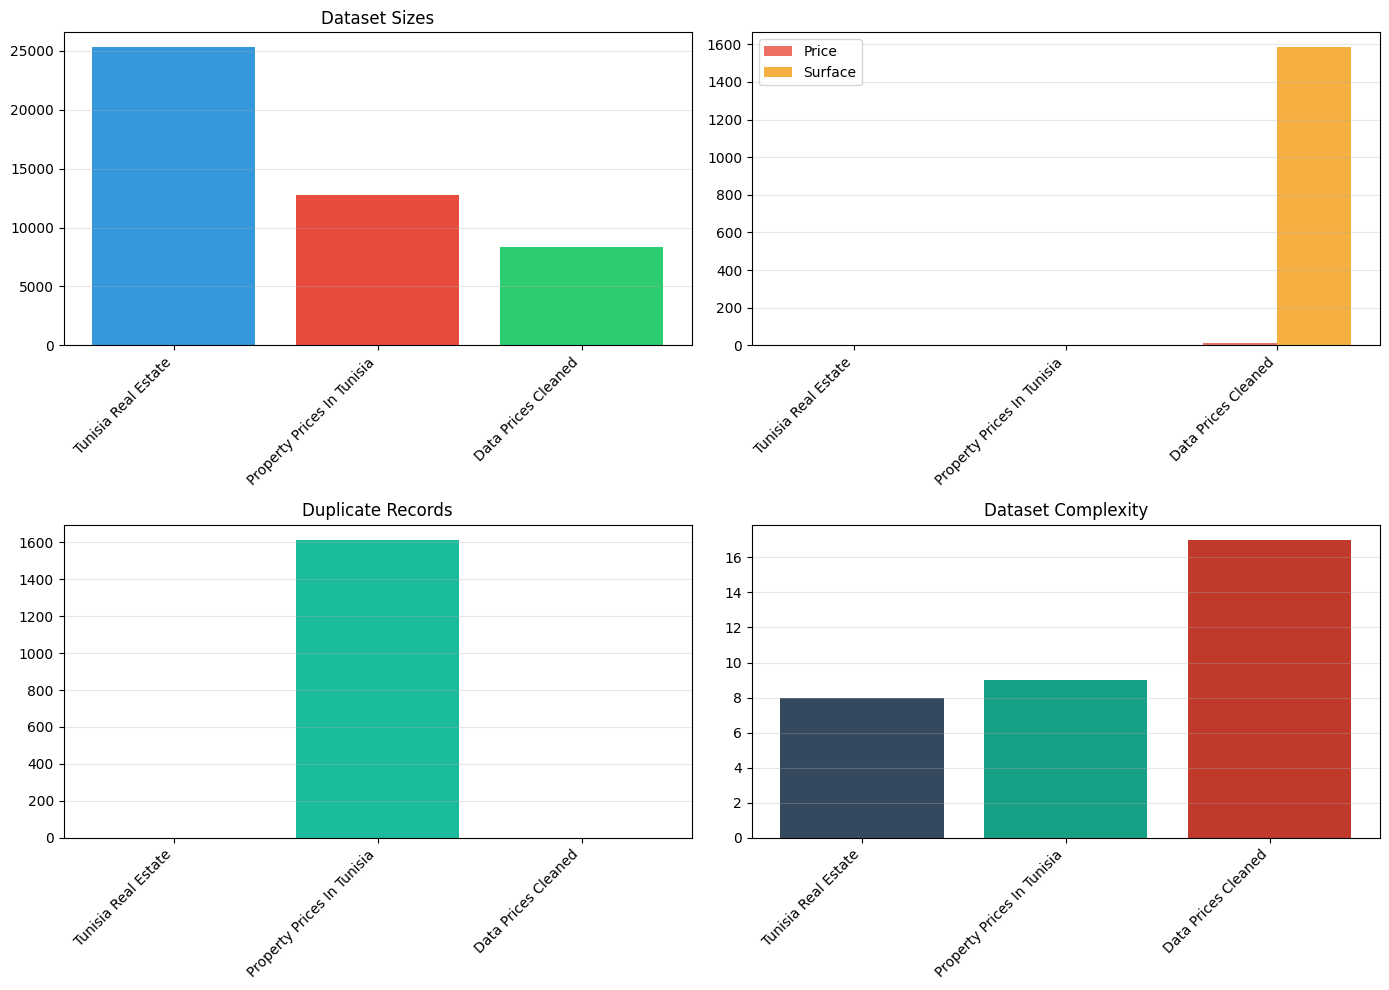

✓ Dataset discovery visualizations complete


In [12]:
# Visualize dataset discovery results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
dataset_names = [p['dataset_name'].replace('_', ' ').title() for p in profiles]
dataset_rows = [p['rows'] for p in profiles]

axes[0, 0].bar(range(len(dataset_names)), dataset_rows, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_xticks(range(len(dataset_names)))
axes[0, 0].set_xticklabels(dataset_names, rotation=45, ha='right')
axes[0, 0].set_title('Dataset Sizes')
axes[0, 0].grid(axis='y', alpha=0.3)

missing_data = pd.DataFrame([
    {
        'Dataset': p['dataset_name'].replace('_', ' ').title(),
        'Price Missing': p['price_missing'] or 0,
        'Surface Missing': p['surface_missing'] or 0,
    }
    for p in profiles
])
x = range(len(missing_data))
width = 0.35
axes[0, 1].bar([i - width/2 for i in x], missing_data['Price Missing'], width, label='Price', color='#e74c3c', alpha=0.8)
axes[0, 1].bar([i + width/2 for i in x], missing_data['Surface Missing'], width, label='Surface', color='#f39c12', alpha=0.8)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(missing_data['Dataset'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

duplicates = [p['duplicate_rows_exact'] for p in profiles]
axes[1, 0].bar(range(len(dataset_names)), duplicates, color=['#9b59b6', '#1abc9c', '#e67e22'])
axes[1, 0].set_xticks(range(len(dataset_names)))
axes[1, 0].set_xticklabels(dataset_names, rotation=45, ha='right')
axes[1, 0].set_title('Duplicate Records')
axes[1, 0].grid(axis='y', alpha=0.3)

column_counts = [p['column_count'] for p in profiles]
axes[1, 1].bar(range(len(dataset_names)), column_counts, color=['#34495e', '#16a085', '#c0392b'])
axes[1, 1].set_xticks(range(len(dataset_names)))
axes[1, 1].set_xticklabels(dataset_names, rotation=45, ha='right')
axes[1, 1].set_title('Dataset Complexity')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Dataset discovery visualizations complete')


### The Cleaning Challenge

Each dataset needs different transformations:
- **tunisia_real_estate**: Has "Nature" field to filter sales, needs room count extraction
- **property_prices_in_tunisia**: Has "type" and "category" fields, includes "autres villes" placeholder
- **data_prices_cleaned**: Has "transaction" field, location is combined "state, city" format

All three must be transformed to the same canonical schema with consistent data types and valid ranges.

<a id='6'></a>
## 6. Stage 2: Dataset Cleaning

### Purpose

Standardize all datasets to a common schema and remove invalid records.

### Canonical Schema

All datasets are transformed to these columns:
- `source_dataset` - Origin dataset name
- `source_row_id` - Original row index
- `property_family` - apartment | house | land
- `governorate` - Standardized governorate name
- `delegation` - Standardized delegation name
- `city` - Standardized city name
- `location` - Free-text location
- `surface_m2` - Surface area in square meters
- `rooms` - Number of rooms (0 for land)
- `bathrooms` - Number of bathrooms
- `price_tnd` - Price in Tunisian Dinars

### Cleaning Steps

1. Fix text encoding issues (UTF-8, Latin-1, CP1252)
2. Standardize governorate and city names
3. Infer property family from type/category fields
4. Remove non-sale records (rentals, offices)
5. Remove invalid prices and surfaces
6. Apply property-specific range filters
7. Deduplicate within each dataset

In [13]:
# Canonical columns
CANONICAL_COLUMNS = [
    "source_dataset", "source_row_id", "property_family",
    "governorate", "delegation", "city", "location",
    "surface_m2", "rooms", "bathrooms", "price_tnd"
]

ALLOWED_FAMILIES = {"apartment", "house", "land"}

# Governorate standardization
CANONICAL_GOVERNORATES = {
    "ariana": "Ariana", "beja": "Beja", "ben arous": "Ben Arous",
    "bizerte": "Bizerte", "gabes": "Gabes", "gafsa": "Gafsa",
    "jendouba": "Jendouba", "kairouan": "Kairouan", "kasserine": "Kasserine",
    "kebili": "Kebili", "kef": "Le Kef", "le kef": "Le Kef",
    "mahdia": "Mahdia", "manouba": "Manouba", "medenine": "Medenine",
    "monastir": "Monastir", "nabeul": "Nabeul", "sfax": "Sfax",
    "sidi bouzid": "Sidi Bouzid", "siliana": "Siliana", "sousse": "Sousse",
    "tataouine": "Tataouine", "tozeur": "Tozeur", "tunis": "Tunis",
    "zaghouan": "Zaghouan"
}

print("✓ Canonical schema and governorates defined")


✓ Canonical schema and governorates defined


In [14]:
# Property family inference
def infer_property_family(*values: Any) -> str:
    """Infer property type from text fields."""
    blob = " ".join(normalize_text(v) for v in values if repair_text(v))
    if any(token in blob for token in ("terrain", "land", "ferme", "vacant land", "lot")):
        return "land"
    if any(token in blob for token in ("villa", "maison", "house", "duplex", "immeuble")):
        return "house"
    if any(token in blob for token in ("appart", "apartment", "studio", "flat", "residence", "s 1", "s 2")):
        return "apartment"
    return "other"

def clean_governorate(value: Any) -> str:
    """Standardize governorate name."""
    key = normalize_text(value)
    return CANONICAL_GOVERNORATES.get(key, repair_text(value)) if key else ""

def title_case_text(value: Any) -> str:
    """Convert to title case."""
    text = repair_text(value)
    return " ".join(part.capitalize() for part in text.split()) if text else ""

print("✓ Cleaning helper functions defined")


✓ Cleaning helper functions defined


In [15]:
# Finalize cleaned frame
def finalize_clean_frame(name: str, frame: pd.DataFrame) -> pd.DataFrame:
    """Apply final cleaning and filtering."""
    cleaned = frame.copy()
    
    # Ensure all canonical columns exist
    for col in CANONICAL_COLUMNS:
        if col not in cleaned.columns:
            cleaned[col] = None
    
    cleaned = cleaned[CANONICAL_COLUMNS].copy()
    
    # Convert numeric columns
    cleaned["surface_m2"] = pd.to_numeric(cleaned["surface_m2"], errors="coerce")
    cleaned["rooms"] = pd.to_numeric(cleaned["rooms"], errors="coerce")
    cleaned["bathrooms"] = pd.to_numeric(cleaned["bathrooms"], errors="coerce")
    cleaned["price_tnd"] = pd.to_numeric(cleaned["price_tnd"], errors="coerce")
    
    # Fix invalid room/bathroom counts
    cleaned.loc[(cleaned["rooms"] < 0) | (cleaned["rooms"] > 20), "rooms"] = np.nan
    cleaned.loc[(cleaned["bathrooms"] < 0) | (cleaned["bathrooms"] > 10), "bathrooms"] = np.nan
    
    # Land has 0 rooms/bathrooms
    cleaned.loc[cleaned["property_family"] == "land", "rooms"] = 0
    cleaned.loc[cleaned["property_family"] == "land", "bathrooms"] = 0
    
    # Calculate price per m2 for filtering
    cleaned["price_per_m2"] = cleaned["price_tnd"] / cleaned["surface_m2"]
    
    # Apply property-specific range filters
    apartment_mask = cleaned["property_family"] == "apartment"
    house_mask = cleaned["property_family"] == "house"
    land_mask = cleaned["property_family"] == "land"
    
    cleaned = cleaned[
        (~apartment_mask | (cleaned["surface_m2"].between(15, 500) & cleaned["price_tnd"].between(30000, 5000000)))
        & (~house_mask | (cleaned["surface_m2"].between(40, 2000) & cleaned["price_tnd"].between(50000, 30000000)))
        & (~land_mask | (cleaned["surface_m2"].between(50, 50000) & cleaned["price_tnd"].between(2000, 50000000)))
    ].copy()
    
    # Recompute masks after row filtering to avoid boolean index misalignment warnings
    apartment_mask = cleaned["property_family"] == "apartment"
    house_mask = cleaned["property_family"] == "house"
    land_mask = cleaned["property_family"] == "land"

    # Price per m2 filters
    cleaned = cleaned[
        (~apartment_mask | cleaned["price_per_m2"].between(300, 20000))
        & (~house_mask | cleaned["price_per_m2"].between(300, 20000))
        & (~land_mask | cleaned["price_per_m2"].between(10, 15000))
    ].copy()
    
    # Keep only training-usable rows
    cleaned = cleaned[
        cleaned["property_family"].isin(ALLOWED_FAMILIES)
        & cleaned["governorate"].ne("")
        & cleaned["city"].ne("")
        & cleaned["surface_m2"].notna()
        & cleaned["price_tnd"].notna()
        & (cleaned["surface_m2"] > 0)
        & (cleaned["price_tnd"] > 0)
    ].copy()
    
    # Deduplicate
    cleaned = cleaned.drop_duplicates(subset=["property_family", "governorate", "city", "surface_m2", "price_tnd", "rooms"])
    cleaned = cleaned.drop(columns=["price_per_m2"])
    cleaned = cleaned.reset_index(drop=True)
    cleaned["source_dataset"] = name
    cleaned["source_row_id"] = cleaned["source_row_id"].astype(str)
    
    return cleaned

print("✓ finalize_clean_frame function defined")


✓ finalize_clean_frame function defined


In [16]:
# Clean tunisia_real_estate dataset
def clean_tunisia_real_estate(path: Path) -> pd.DataFrame:
    """Clean the tunisia-real-estate.csv dataset."""
    raw = read_csv_any(path).reset_index().rename(columns={"index": "source_row_id"})
    nature = raw["Nature"].map(repair_text)
    family = raw.apply(lambda row: infer_property_family(row.get("Type of Real Estate"), row.get("Nature")), axis=1)
    
    cleaned = pd.DataFrame({
        "source_row_id": raw["source_row_id"],
        "property_family": family,
        "governorate": raw["Governorate"].map(clean_governorate),
        "delegation": raw["Delegation"].map(title_case_text),
        "city": raw["Locality"].map(title_case_text),
        "location": raw["Locality"].map(title_case_text),
        "surface_m2": raw["Surface"].map(parse_float),
        "rooms": None,
        "bathrooms": None,
        "price_tnd": raw["Price"].map(parse_float),
    })
    
    # Keep only sale records
    sale_like = nature.map(normalize_text).isin({"sale", "land"})
    cleaned = cleaned[sale_like].copy()
    
    return finalize_clean_frame("tunisia_real_estate", cleaned)

print("✓ clean_tunisia_real_estate function defined")


✓ clean_tunisia_real_estate function defined


In [17]:
# Clean property_prices_in_tunisia dataset
def clean_property_prices_in_tunisia(path: Path) -> pd.DataFrame:
    """Clean the Property Prices in Tunisia.csv dataset."""
    raw = read_csv_any(path).reset_index().rename(columns={"index": "source_row_id"})
    type_key = raw["type"].map(normalize_text)
    category_key = raw["category"].map(normalize_text)
    
    allowed_categories = {
        "appartements": "apartment",
        "maisons et villas": "house",
        "terrains et fermes": "land",
    }
    
    cleaned = pd.DataFrame({
        "source_row_id": raw["source_row_id"],
        "property_family": category_key.map(allowed_categories).fillna("other"),
        "governorate": raw["city"].map(clean_governorate),
        "delegation": raw["region"].map(title_case_text),
        "city": raw["region"].map(title_case_text),
        "location": raw["region"].map(title_case_text),
        "surface_m2": raw["size"].map(parse_float),
        "rooms": raw["room_count"].map(parse_int),
        "bathrooms": raw["bathroom_count"].map(parse_int),
        "price_tnd": raw["price"].map(parse_float),
    })
    
    # Filter for sale records only
    sale_like = type_key.eq("a vendre")
    wanted_family = cleaned["property_family"].isin(ALLOWED_FAMILIES)
    valid_region = raw["region"].map(normalize_text).ne("autres villes")
    cleaned = cleaned[sale_like & wanted_family & valid_region].copy()
    
    return finalize_clean_frame("property_prices_in_tunisia", cleaned)

print("✓ clean_property_prices_in_tunisia function defined")


✓ clean_property_prices_in_tunisia function defined


### Visualization: Cleaning Results

Let's see how cleaning affected each dataset and the distribution of cleaned data.

In [18]:
# Clean data_prices_cleaned dataset
def clean_data_prices_cleaned(path: Path) -> pd.DataFrame:
    """Clean the data_prices_cleaned.csv dataset."""
    raw = read_csv_any(path).reset_index().rename(columns={"index": "source_row_id"})
    category_key = raw["category"].map(normalize_text)
    
    allowed_categories = {
        "appartements": "apartment",
        "maisons et villas": "house",
        "terrains et fermes": "land",
    }
    
    cleaned = pd.DataFrame({
        "source_row_id": raw["source_row_id"],
        "property_family": category_key.map(allowed_categories).fillna("other"),
        "governorate": raw["state"].map(clean_governorate),
        "delegation": raw["city"].map(title_case_text),
        "city": raw["city"].map(title_case_text),
        "location": raw["location"].map(repair_text),
        "surface_m2": raw["superficie"].map(parse_float),
        "rooms": raw["chambres"].map(parse_int),
        "bathrooms": raw["salles_de_bains"].map(parse_int),
        "price_tnd": raw["price"].map(parse_float),
    })
    
    sale_like = raw["transaction"].map(normalize_text).eq("sale")
    wanted_family = cleaned["property_family"].isin(ALLOWED_FAMILIES)
    cleaned = cleaned[sale_like & wanted_family].copy()
    return finalize_clean_frame("data_prices_cleaned", cleaned)

print("✓ clean_data_prices_cleaned function defined")


✓ clean_data_prices_cleaned function defined


In [19]:
# Run cleaning on all datasets
print("Running dataset cleaning...\n")

cleaned_frames = {}
for name, path in DATASETS.items():
    print(f"Cleaning {name}...")
    
    if name == "tunisia_real_estate":
        cleaned = clean_tunisia_real_estate(path)
    elif name == "property_prices_in_tunisia":
        cleaned = clean_property_prices_in_tunisia(path)
    else:
        cleaned = clean_data_prices_cleaned(path)
    
    cleaned_frames[name] = cleaned
    output_path = CLEANING_DIR / f"02_{name}_clean.csv"
    cleaned.to_csv(output_path, index=False)
    
    print(f"  Input rows: {pd.read_csv(path).shape[0]:,}")
    print(f"  Output rows: {len(cleaned):,}")
    print(f"  Saved to: {output_path.name}")
    print()

print(f"✓ Cleaning complete. Files saved to {CLEANING_DIR}")


Running dataset cleaning...

Cleaning tunisia_real_estate...
  Input rows: 25,317
  Output rows: 9,038
  Saved to: 02_tunisia_real_estate_clean.csv

Cleaning property_prices_in_tunisia...
  Input rows: 12,748
  Output rows: 2,920
  Saved to: 02_property_prices_in_tunisia_clean.csv

Cleaning data_prices_cleaned...
  Input rows: 8,336
  Output rows: 1,764
  Saved to: 02_data_prices_cleaned_clean.csv

✓ Cleaning complete. Files saved to c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\02_cleaning


In [20]:
# Display cleaning summary
cleaning_summary = pd.DataFrame([
    {
        "Dataset": name,
        "Cleaned Rows": len(frame),
        "Families": frame["property_family"].nunique(),
        "Governorates": frame["governorate"].nunique(),
        "Cities": frame["city"].nunique(),
    }
    for name, frame in cleaned_frames.items()
])

print("\n=== Dataset Cleaning Summary ===")
print(cleaning_summary.to_string(index=False))



=== Dataset Cleaning Summary ===
                   Dataset  Cleaned Rows  Families  Governorates  Cities
       tunisia_real_estate          9038         3            24     164
property_prices_in_tunisia          2920         2            23     187
       data_prices_cleaned          1764         2            18     175


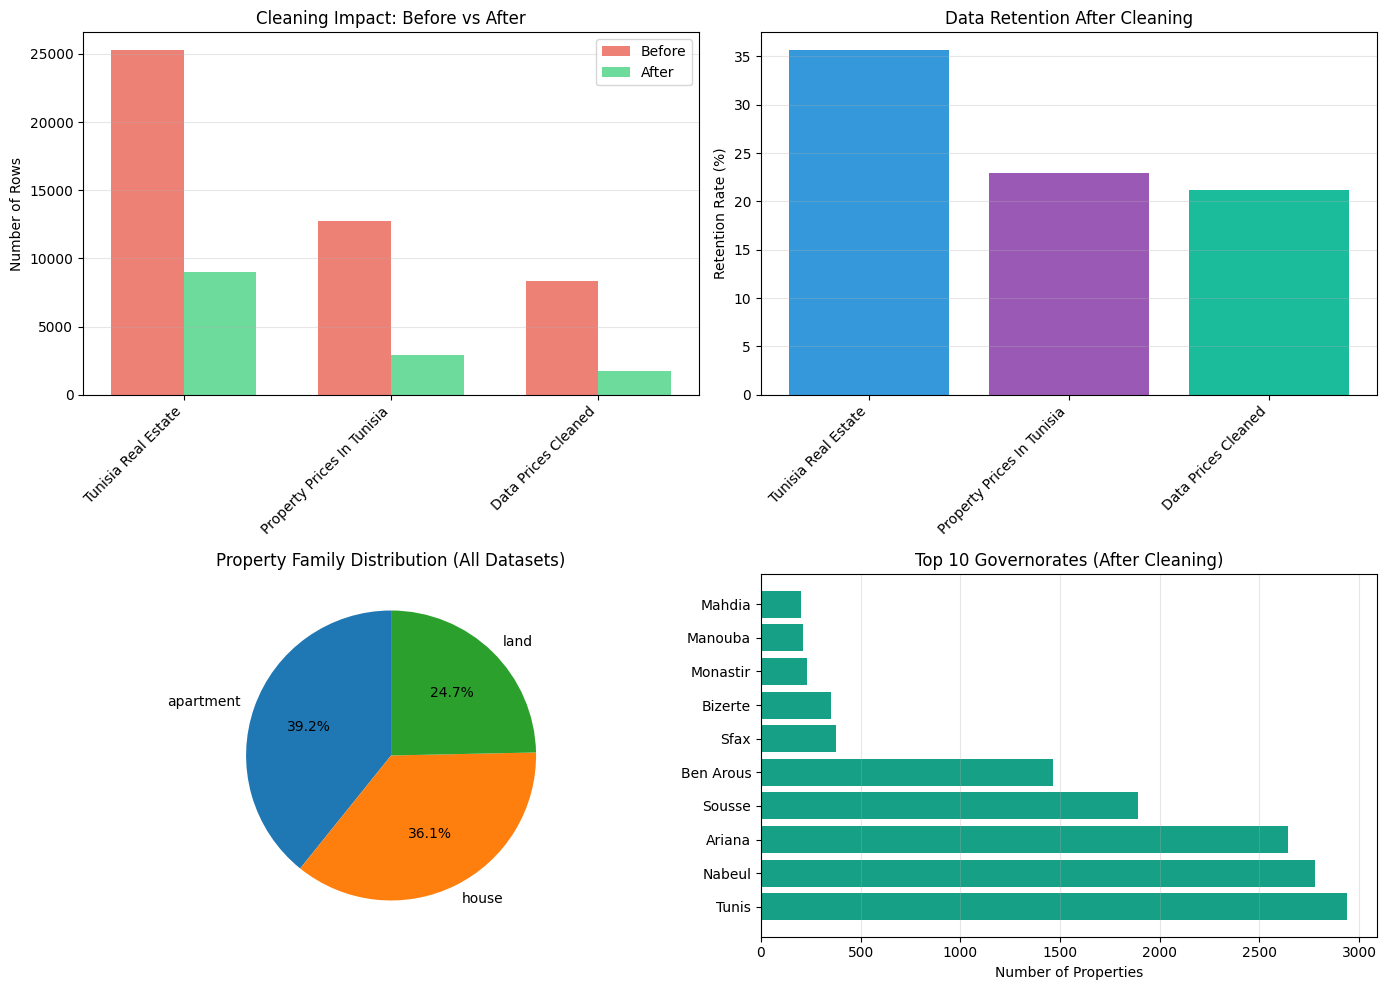

✓ Cleaning visualizations complete


In [21]:
# Visualize cleaning results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

dataset_names_clean = list(cleaned_frames.keys())
before_counts = [pd.read_csv(DATASETS[name]).shape[0] for name in dataset_names_clean]
after_counts = [len(cleaned_frames[name]) for name in dataset_names_clean]

x = range(len(dataset_names_clean))
width = 0.35

axes[0, 0].bar([i - width/2 for i in x], before_counts, width, label='Before', color='#e74c3c', alpha=0.7)
axes[0, 0].bar([i + width/2 for i in x], after_counts, width, label='After', color='#2ecc71', alpha=0.7)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([n.replace('_', ' ').title() for n in dataset_names_clean], rotation=45, ha='right')
axes[0, 0].set_ylabel('Number of Rows')
axes[0, 0].set_title('Cleaning Impact: Before vs After')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

retention_rates = [(after / before) * 100 for before, after in zip(before_counts, after_counts)]
axes[0, 1].bar(x, retention_rates, color=['#3498db', '#9b59b6', '#1abc9c'])
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels([n.replace('_', ' ').title() for n in dataset_names_clean], rotation=45, ha='right')
axes[0, 1].set_ylabel('Retention Rate (%)')
axes[0, 1].set_title('Data Retention After Cleaning')
axes[0, 1].grid(axis='y', alpha=0.3)

all_families = pd.concat([df['property_family'] for df in cleaned_frames.values()])
family_counts = all_families.value_counts()
axes[1, 0].pie(family_counts.values, labels=family_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Property Family Distribution (All Datasets)')

all_governorates = pd.concat([df['governorate'] for df in cleaned_frames.values()])
gov_counts = all_governorates.value_counts().head(10)
axes[1, 1].barh(range(len(gov_counts)), gov_counts.values, color='#16a085')
axes[1, 1].set_yticks(range(len(gov_counts)))
axes[1, 1].set_yticklabels(gov_counts.index)
axes[1, 1].set_xlabel('Number of Properties')
axes[1, 1].set_title('Top 10 Governorates (After Cleaning)')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Cleaning visualizations complete")


### Why Merge Matters

The same property might appear in multiple datasets (cross-source duplicates). We need to:
1. Combine all cleaned datasets
2. Detect duplicates based on key fields (family, location, surface, price, rooms)
3. Keep only the highest-priority source for each property

This prevents the model from training on the same property multiple times.

<a id='7'></a>
## 7. Stage 3: Merge Preparation

### Purpose

Combine all cleaned datasets and handle cross-source duplicates.

### Process

1. Load all cleaned datasets
2. Concatenate into single dataframe
3. Detect cross-source duplicates (same property listed in multiple sources)
4. Keep highest-priority source for each duplicate
5. Generate merge report

### Source Priority

When the same property appears in multiple datasets, we keep the record from:
1. tunisia_real_estate (highest priority)
2. property_prices_in_tunisia
3. data_prices_cleaned (lowest priority)

### Visualization: Merge Analysis

Visualize how data from different sources was combined and deduplicated.

In [22]:
# Define source priority
SOURCE_PRIORITY = {
    "tunisia_real_estate": 1,
    "property_prices_in_tunisia": 2,
    "data_prices_cleaned": 3,
}

DEDUP_COLUMNS = ["property_family", "governorate", "city", "surface_m2", "price_tnd", "rooms"]
print("✓ Merge configuration defined")


✓ Merge configuration defined


In [23]:
# Define source priority
SOURCE_PRIORITY = {
    "tunisia_real_estate": 1,
    "property_prices_in_tunisia": 2,
    "data_prices_cleaned": 3,
}

# Deduplication columns (defines what makes a "duplicate")
DEDUP_COLUMNS = ["property_family", "governorate", "city", "surface_m2", "price_tnd", "rooms"]

print("✓ Merge configuration defined")


✓ Merge configuration defined


In [24]:
# Load and merge cleaned datasets
print("Merging cleaned datasets...\n")

frames_to_merge = []
for name in ["tunisia_real_estate", "property_prices_in_tunisia", "data_prices_cleaned"]:
    path = CLEANING_DIR / f"02_{name}_clean.csv"
    frame = pd.read_csv(path)
    frame["source_dataset"] = name
    frames_to_merge.append(frame)
    print(f"Loaded {name}: {len(frame):,} rows")

merged_raw = pd.concat(frames_to_merge, ignore_index=True)
merged_raw["source_priority"] = merged_raw["source_dataset"].map(SOURCE_PRIORITY).fillna(999).astype(int)

print(f"\nTotal rows before deduplication: {len(merged_raw):,}")


Merging cleaned datasets...

Loaded tunisia_real_estate: 9,038 rows
Loaded property_prices_in_tunisia: 2,920 rows
Loaded data_prices_cleaned: 1,764 rows

Total rows before deduplication: 13,722


In [25]:
# Detect and remove cross-source duplicates
duplicate_mask = merged_raw.duplicated(subset=DEDUP_COLUMNS, keep=False)
num_duplicates = duplicate_mask.sum()

print(f"Cross-source duplicate rows detected: {num_duplicates:,}")

# Deduplicate: keep highest priority source
merged_final = merged_raw.sort_values(DEDUP_COLUMNS + ["source_priority", "source_dataset", "source_row_id"])
merged_final = merged_final.drop_duplicates(subset=DEDUP_COLUMNS, keep="first")
merged_final = merged_final.drop(columns=["source_priority"]).reset_index(drop=True)

print(f"Rows after deduplication: {len(merged_final):,}")
print(f"Rows removed: {len(merged_raw) - len(merged_final):,}")


Cross-source duplicate rows detected: 6
Rows after deduplication: 13,719
Rows removed: 3


In [26]:
# Save merged dataset
output_path = MERGE_DIR / "03_final_merge_ready.csv"
merged_final.to_csv(output_path, index=False)

# Generate merge report
merge_report = {
    "stage": "03_merge_preparation",
    "input_rows": int(len(merged_raw)),
    "rows_removed_as_cross_source_duplicates": int(len(merged_raw) - len(merged_final)),
    "final_rows": int(len(merged_final)),
    "source_priority": SOURCE_PRIORITY,
    "source_distribution": merged_final["source_dataset"].value_counts().to_dict(),
}

write_json(MERGE_DIR / "03_merge_report.json", merge_report)

print(f"\n✓ Merged dataset saved: {output_path}")
print(f"✓ Report saved: {MERGE_DIR / '03_merge_report.json'}")



✓ Merged dataset saved: c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\03_merge\03_final_merge_ready.csv
✓ Report saved: c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\03_merge\03_merge_report.json


### The Geographic Challenge

Raw listings use informal location names:
- "L'Aouina" vs "Laouina" vs "Aouina"
- "Cité Ennasr" vs "Ennasr" vs "Cite Ennasr 2"
- Misspellings and encoding issues

We need to match these to **official delegation boundaries** from GeoJSON. This enables:
- Consistent location encoding
- Geographic feature extraction
- Spatial analysis

We use multiple strategies: exact match → fuzzy match → manual overrides.

### Visualization: Geographic Alignment Results

See how well we matched location names to official boundaries.

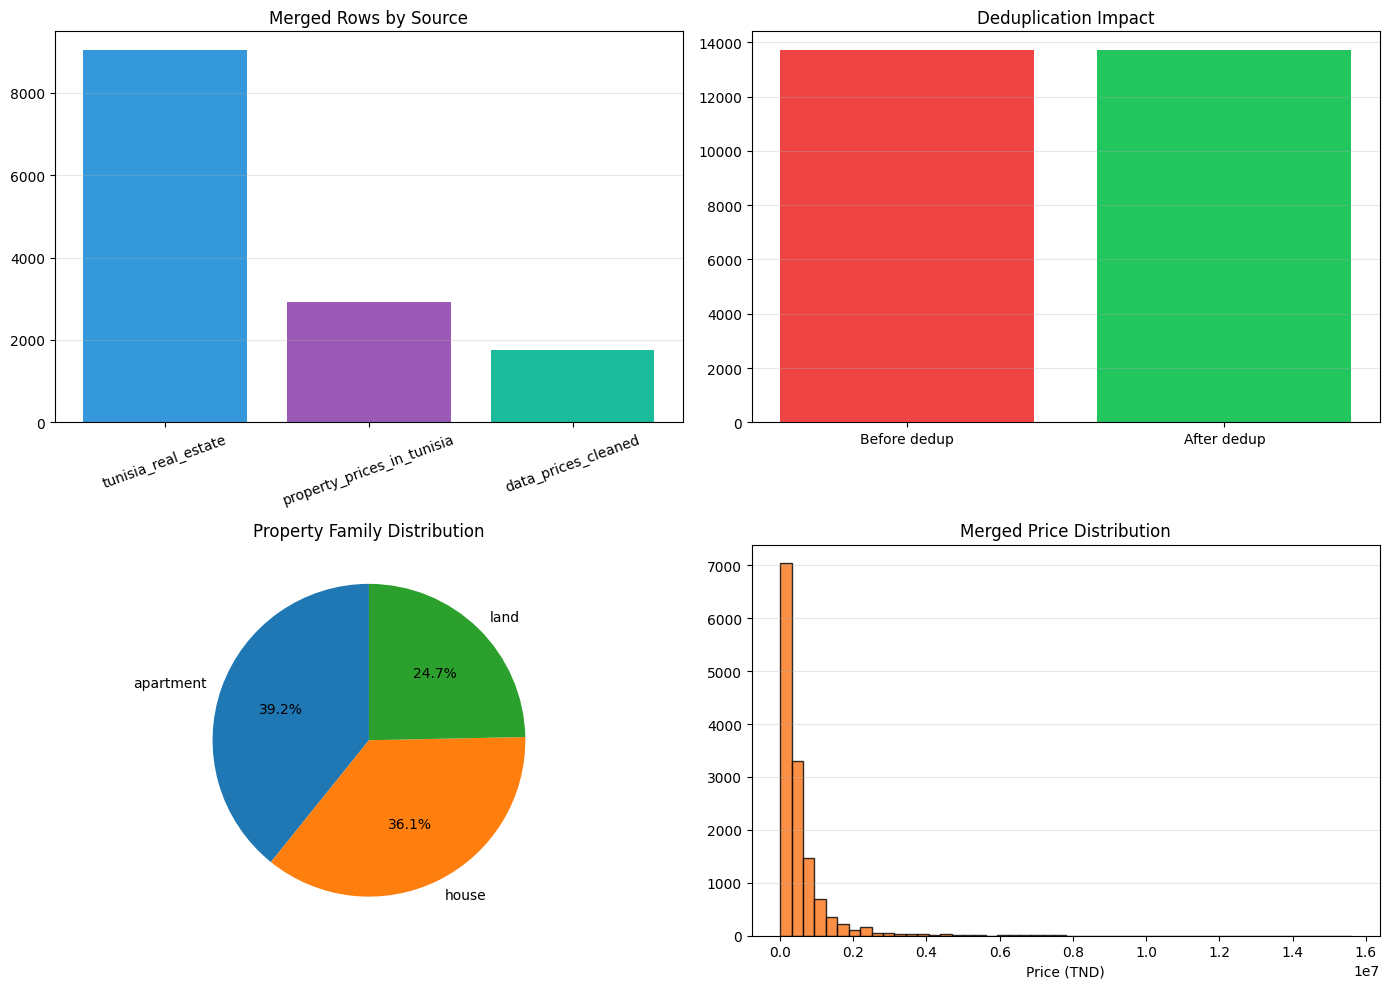

✓ Merge visualizations complete


In [27]:
# Visualize merge results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

source_counts = merged_final['source_dataset'].value_counts()
axes[0, 0].bar(source_counts.index, source_counts.values, color=['#3498db', '#9b59b6', '#1abc9c'])
axes[0, 0].set_title('Merged Rows by Source')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(['Before dedup', 'After dedup'], [len(merged_raw), len(merged_final)], color=['#ef4444', '#22c55e'])
axes[0, 1].set_title('Deduplication Impact')
axes[0, 1].grid(axis='y', alpha=0.3)

family_counts = merged_final['property_family'].value_counts()
axes[1, 0].pie(family_counts.values, labels=family_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Property Family Distribution')

price_sample = merged_final['price_tnd'].dropna()
axes[1, 1].hist(price_sample, bins=50, color='#f97316', alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Merged Price Distribution')
axes[1, 1].set_xlabel('Price (TND)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Merge visualizations complete')


In [28]:
# Load geographic reference data
print("Loading geographic reference data...\n")

geojson_path = GEO_DIR / "delegations-full.geojson"
with open(geojson_path, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

geo_rows = []
for feature in geojson_data.get("features", []):
    props = feature.get("properties", {})
    feature_type = normalize_text(props.get("type_2") or props.get("engtype_2"))
    if feature_type != "delegation":
        continue
    governorate = clean_governorate(props.get("gov_name_f") or props.get("name_1"))
    delegation = title_case_text(props.get("deleg_na_1") or props.get("name_2"))
    if governorate and delegation:
        geo_rows.append({
            "governorate": governorate,
            "delegation": delegation,
            "governorate_norm": normalize_text(governorate),
            "delegation_norm": normalize_text(delegation),
        })

geo_frame = pd.DataFrame(geo_rows).drop_duplicates(subset=["governorate_norm", "delegation_norm"]).reset_index(drop=True)
print(f"✓ Loaded {len(geo_frame)} official delegations")
print(f"  Governorates: {geo_frame['governorate'].nunique()}")


Loading geographic reference data...

✓ Loaded 265 official delegations
  Governorates: 24


<a id='8'></a>
## 8. Stage 4: Geographic Name Alignment

### Purpose

Match city/delegation names from listings to official administrative boundaries.

### Challenge

Raw datasets contain inconsistent location names:
- Spelling variations ("L'Aouina" vs "Laouina")
- Encoding issues ("Cité" vs "Cit�")
- Informal names vs official names
- Missing delegation information

### Solution

Multi-strategy matching:
1. **Exact delegation match** - Direct lookup in GeoJSON
2. **Exact locality match** - Lookup in tunisia.json locality database
3. **Substring match** - Partial text matching
4. **Fuzzy match** - Similarity-based matching (88%+ threshold)
5. **Manual overrides** - Hardcoded mappings for known cases

### Geographic Reference

- **delegations-full.geojson** - 264 official delegations with boundaries
- **tunisia.json** - Locality-to-delegation mappings

In [29]:
# Build lookup dictionaries
exact_delegations = {}
for row in geo_frame.to_dict("records"):
    exact_delegations.setdefault(row["delegation_norm"], []).append(row)

print(f"✓ Built delegation lookup dictionary ({len(exact_delegations)} keys)")


✓ Built delegation lookup dictionary (264 keys)


In [30]:
# Build lookup dictionaries
exact_delegations = {}
for row in geo_frame.to_dict("records"):
    exact_delegations.setdefault(row["delegation_norm"], []).append(row)

print(f"✓ Built delegation lookup dictionary ({len(exact_delegations)} keys)")


✓ Built delegation lookup dictionary (264 keys)


### Visualization: Training Dataset Analysis

Explore the characteristics of our final training-ready dataset.

In [31]:
# Fuzzy matching function
def best_fuzzy_delegation(term_norm: str, governorate_norm: str, geo_frame: pd.DataFrame) -> dict | None:
    """Find best fuzzy match for delegation name."""
    candidates = geo_frame[geo_frame["governorate_norm"] == governorate_norm].copy()
    if candidates.empty or not term_norm:
        return None
    candidates["score"] = candidates["delegation_norm"].map(lambda v: SequenceMatcher(None, term_norm, v).ratio())
    best = candidates.sort_values("score", ascending=False).iloc[0]
    if float(best["score"]) < 0.88:
        return None
    return {
        "governorate": str(best["governorate"]),
        "delegation": str(best["delegation"]),
        "governorate_norm": str(best["governorate_norm"]),
        "delegation_norm": str(best["delegation_norm"]),
    }

print("✓ Fuzzy matching function defined")


✓ Fuzzy matching function defined


In [32]:
# Load geographic alignment outputs
aligned_frame = pd.read_csv(GEO_ALIGNMENT_DIR / "04_geo_aligned_dataset.csv")
alignment_report = json.loads((GEO_ALIGNMENT_DIR / "04_geo_alignment_report.json").read_text(encoding="utf-8"))
unmatched = pd.read_csv(GEO_ALIGNMENT_DIR / "04_geo_unmatched_rows.csv")

print("\n=== Alignment Summary ===")
for status, count in alignment_report["match_status"].items():
    print(f"{status}: {count:,}")
print(f"\nUnique geo delegations covered: {alignment_report['unique_geo_delegations_covered']}")
print(f"Unmatched rows: {alignment_report['unmatched_rows']:,}")



=== Alignment Summary ===
exact_delegation: 7,947
manual_override: 4,684
exact_locality: 995
fuzzy_delegation: 92
substring_locality: 38
unmatched: 32

Unique geo delegations covered: 181
Unmatched rows: 32


### Creating the Training Dataset

Now we filter for model-ready records. Requirements:
- Valid property family (apartment, house, or land)
- Complete geographic information (governorate, delegation, locality)
- Valid numeric values (surface > 0, price > 0)
- No missing critical fields

We also add derived features:
- `price_per_m2` = price / surface
- `log_price_tnd` = ln(price) - for modeling
- `log_price_per_m2` = ln(price_per_m2)

Log transformation helps with the wide price range and makes the target more normally distributed.

In [33]:
# Inspect top unmatched locality pairs
top_unmatched = pd.DataFrame(alignment_report.get("top_unmatched_pairs", []))

print("\n=== Top Unmatched Locality Pairs ===")
if top_unmatched.empty:
    print("No unmatched rows remaining.")
else:
    print(top_unmatched.head(20).to_string(index=False))



=== Top Unmatched Locality Pairs ===
governorate              city  count
      Tunis Ezzouhour (tunis)     11
     Le Kef      Le Kef Ouest      9
   Jendouba          Jendouba      7
      Tunis         Essijoumi      4
Sidi Bouzid      Bir El Hafey      1


In [34]:
# Display alignment summary
summary_rows = pd.DataFrame([
    {"Match status": key, "Rows": value}
    for key, value in alignment_report["match_status"].items()
]).sort_values("Rows", ascending=False)

print("\n=== Alignment Summary ===")
print(summary_rows.to_string(index=False))
print(f"\nUnique geo delegations covered: {alignment_report['unique_geo_delegations_covered']}")
print(f"Unmatched rows: {alignment_report['unmatched_rows']:,}")



=== Alignment Summary ===
      Match status  Rows
  exact_delegation  7947
   manual_override  4684
    exact_locality   995
  fuzzy_delegation    92
substring_locality    38
         unmatched    32

Unique geo delegations covered: 181
Unmatched rows: 32


### Visualization: Geographic Features

Visualize the geographic distribution of properties with coordinates.

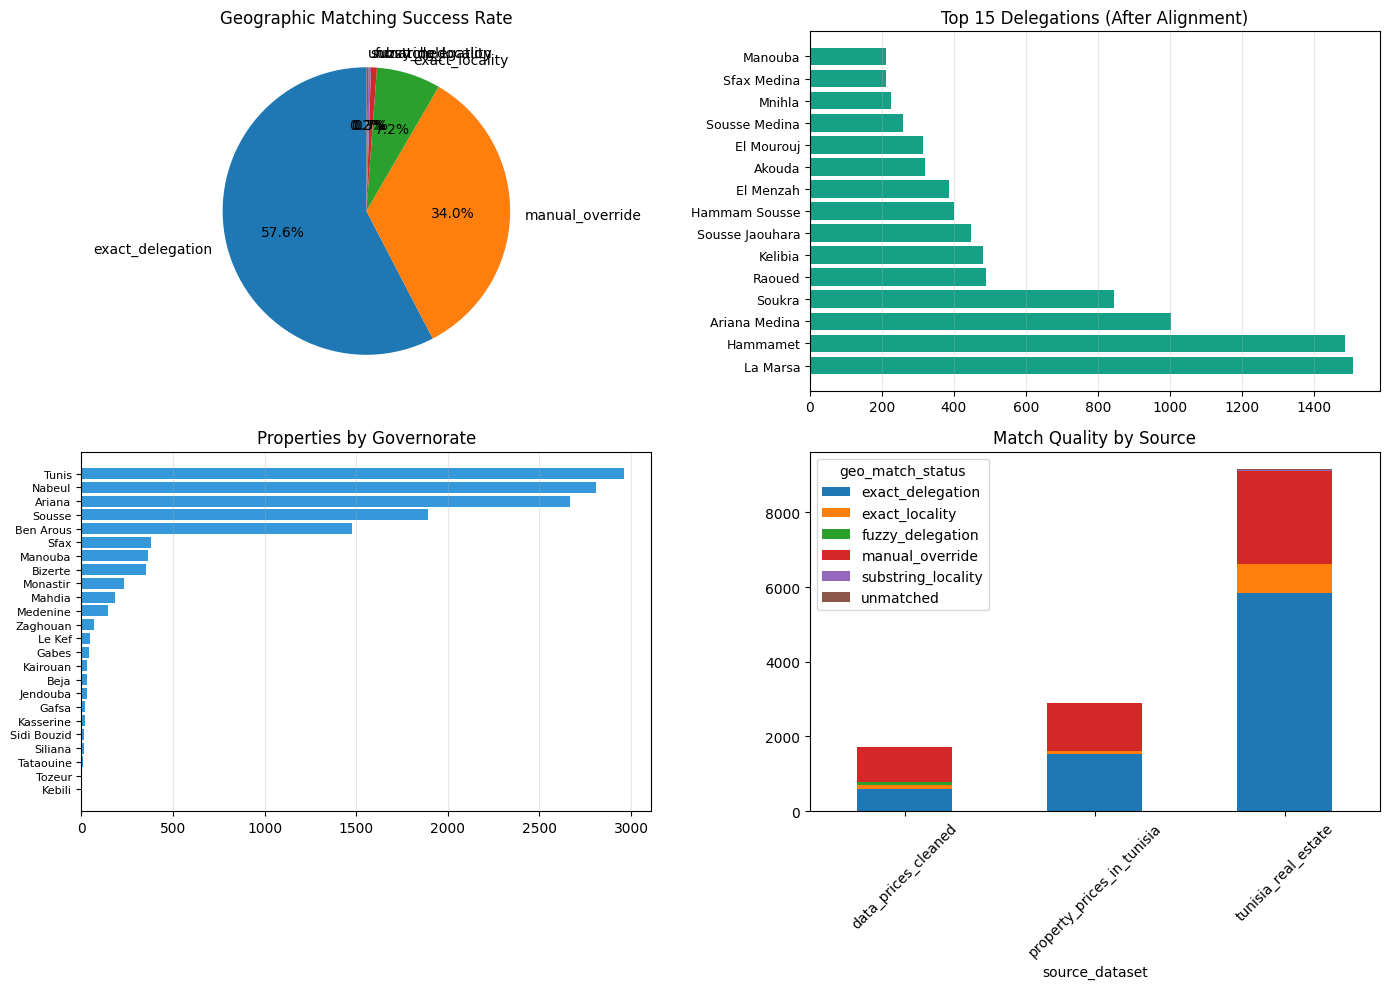

✓ Geographic alignment visualizations complete


In [35]:
# Visualize geographic alignment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

match_status_counts = aligned_frame['geo_match_status'].value_counts()
axes[0, 0].pie(match_status_counts.values, labels=match_status_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Geographic Matching Success Rate')

matched_data = aligned_frame[aligned_frame['geo_delegation'].ne('')]
top_delegations = matched_data['geo_delegation'].value_counts().head(15)
axes[0, 1].barh(range(len(top_delegations)), top_delegations.values, color='#16a085')
axes[0, 1].set_yticks(range(len(top_delegations)))
axes[0, 1].set_yticklabels(top_delegations.index, fontsize=9)
axes[0, 1].set_title('Top 15 Delegations (After Alignment)')
axes[0, 1].grid(axis='x', alpha=0.3)

gov_coverage = matched_data.groupby('geo_governorate').size().sort_values(ascending=True)
axes[1, 0].barh(range(len(gov_coverage)), gov_coverage.values, color='#3498db')
axes[1, 0].set_yticks(range(len(gov_coverage)))
axes[1, 0].set_yticklabels(gov_coverage.index, fontsize=8)
axes[1, 0].set_title('Properties by Governorate')
axes[1, 0].grid(axis='x', alpha=0.3)

match_by_source = aligned_frame.groupby(['source_dataset', 'geo_match_status']).size().unstack(fill_value=0)
match_by_source.plot(kind='bar', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title('Match Quality by Source')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('✓ Geographic alignment visualizations complete')


<a id='9'></a>
## 9. Stage 5: Training Dataset Preparation

### Purpose

Create the final training-ready dataset with only valid, model-usable records.

### Filters Applied

1. **Property family** - Only apartment, house, land
2. **Geographic completeness** - Must have governorate, delegation, and locality
3. **Numeric completeness** - Must have surface and price
4. **Positive values** - Surface and price must be > 0
5. **Deduplication** - Remove exact duplicates by source

### Derived Features

- `price_per_m2` - Price divided by surface
- `log_price_tnd` - Natural log of price (for modeling)
- `log_price_per_m2` - Natural log of price per m2

### Output

Clean, model-ready dataset with consistent schema and no missing critical values.

In [36]:
# Prepare training dataset
print("Preparing training dataset...\n")

aligned_data = pd.read_csv(GEO_ALIGNMENT_DIR / "04_geo_aligned_dataset.csv")

training = aligned_data.copy()

# Convert numeric columns
training["surface_m2"] = pd.to_numeric(training["surface_m2"], errors="coerce")
training["rooms"] = pd.to_numeric(training["rooms"], errors="coerce")
training["price_tnd"] = pd.to_numeric(training["price_tnd"], errors="coerce")

print(f"Input rows: {len(training):,}")

# Apply filters
training = training[
    training["property_family"].isin(["apartment", "house", "land"])
    & training["geo_governorate"].fillna("").astype(str).str.strip().ne("")
    & training["normalized_locality"].fillna("").astype(str).str.strip().ne("")
    & training["surface_m2"].notna()
    & training["price_tnd"].notna()
    & (training["surface_m2"] > 0)
    & (training["price_tnd"] > 0)
].copy()

print(f"After filtering: {len(training):,}")

# Add derived features
training["price_per_m2"] = training["price_tnd"] / training["surface_m2"]
training["log_price_tnd"] = np.log(training["price_tnd"])
training["log_price_per_m2"] = np.log(training["price_per_m2"])

# Land has 0 rooms
training.loc[training["property_family"] == "land", "rooms"] = 0

# Select final columns
TRAINING_COLUMNS = [
    "source_dataset", "source_row_id", "property_family",
    "surface_m2", "rooms", "price_tnd", "price_per_m2",
    "log_price_tnd", "log_price_per_m2",
    "normalized_locality", "geo_governorate", "geo_delegation"
]

training = training[TRAINING_COLUMNS].copy()
training = training.drop_duplicates(subset=["source_dataset", "source_row_id"]).reset_index(drop=True)

print(f"Final training rows: {len(training):,}")


Preparing training dataset...

Input rows: 13,788
After filtering: 13,788
Final training rows: 13,788


### Feature Engineering Strategy

We add features that capture location-based pricing patterns:

1. **Geographic Coordinates** (`lon`, `lat`)
   - Extracted from GeoJSON delegation centroids
   - Enables spatial modeling

2. **Target Encoding** (added during train/test split)
   - Mean log price by delegation and governorate
   - Captures location-specific price levels without high-cardinality one-hot encoding

3. **Price vs Local Median**
   - Ratio of property price to delegation median
   - Identifies premium/discount properties relative to their area

These features help the model learn geographic price patterns.

In [37]:
# Save training dataset
output_path = TRAINING_DATASET_DIR / "05_training_dataset.csv"
training.to_csv(output_path, index=False)

# Generate report
training_report = {
    "rows": int(len(training)),
    "columns": list(training.columns),
    "source_distribution": training["source_dataset"].value_counts().to_dict(),
    "family_distribution": training["property_family"].value_counts().to_dict(),
    "geo_governorate_count": int(training["geo_governorate"].nunique()),
    "geo_delegation_count": int(training["geo_delegation"].nunique()),
    "normalized_locality_count": int(training["normalized_locality"].nunique()),
    "price_range": {
        "min": float(training["price_tnd"].min()),
        "median": float(training["price_tnd"].median()),
        "max": float(training["price_tnd"].max()),
    },
}

write_json(TRAINING_DATASET_DIR / "05_training_dataset_report.json", training_report)

print(f"\n✓ Training dataset saved: {output_path}")
print(f"✓ Governorates: {training_report['geo_governorate_count']}")
print(f"✓ Delegations: {training_report['geo_delegation_count']}")
print(f"✓ Localities: {training_report['normalized_locality_count']}")



✓ Training dataset saved: c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\05_training_dataset\05_training_dataset.csv
✓ Governorates: 24
✓ Delegations: 181
✓ Localities: 293


In [38]:
# Display training dataset summary
print("\n=== Training Dataset Summary ===")
print(f"Total rows: {len(training):,}")
print(f"\nProperty families:")
for family, count in training["property_family"].value_counts().items():
    print(f"  {family}: {count:,}")
print(f"\nPrice range: {training['price_tnd'].min():,.0f} - {training['price_tnd'].max():,.0f} TND")
print(f"Price median: {training['price_tnd'].median():,.0f} TND")
print(f"\nSurface range: {training['surface_m2'].min():.0f} - {training['surface_m2'].max():,.0f} m²")
print(f"Surface median: {training['surface_m2'].median():.0f} m²")



=== Training Dataset Summary ===
Total rows: 13,788

Property families:
  apartment: 5,459
  house: 4,944
  land: 3,385

Price range: 8,400 - 15,600,000 TND
Price median: 318,000 TND

Surface range: 18 - 50,000 m²
Surface median: 210 m²


<a id='10'></a>
## 10. Stage 6: Feature Engineering

### Purpose

Add derived features that improve model performance.

### Features Added

1. **Geographic Coordinates** (`lon`, `lat`)
   - Extract centroid coordinates from GeoJSON for each delegation
   - Enables spatial modeling

2. **Target Encoding** (added during training split)
   - `geo_delegation_target_enc` - Mean log price by delegation
   - `geo_governorate_target_enc` - Mean log price by governorate
   - Captures location-based price patterns

3. **Price vs Local Median**
   - Ratio of property price to delegation median
   - Identifies premium/discount properties

### Why These Features Matter

- **Coordinates** capture geographic proximity and regional patterns
- **Target encoding** leverages location-based price information without high-cardinality one-hot encoding
- **Local price ratio** helps model understand relative pricing within areas

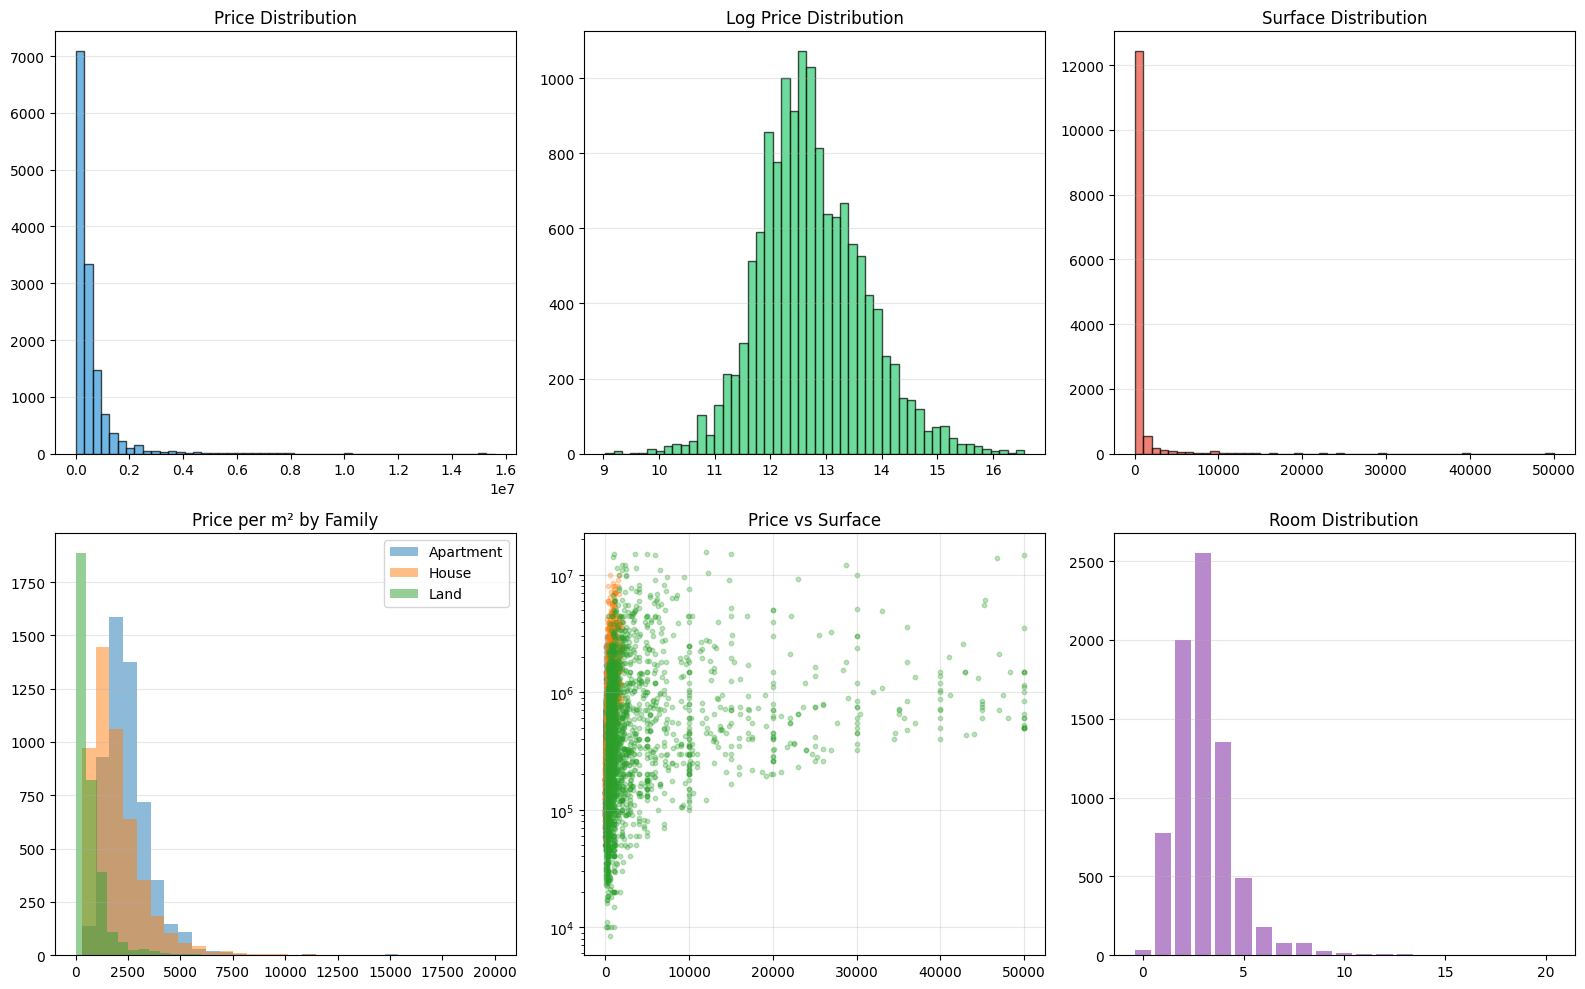

✓ Training dataset visualizations complete


In [39]:
# Visualize training dataset
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(training['price_tnd'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].hist(training['log_price_tnd'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Log Price Distribution')
axes[0, 1].grid(axis='y', alpha=0.3)

axes[0, 2].hist(training['surface_m2'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Surface Distribution')
axes[0, 2].grid(axis='y', alpha=0.3)

for family in training['property_family'].unique():
    family_data = training[training['property_family'] == family]['price_per_m2']
    axes[1, 0].hist(family_data, bins=30, alpha=0.5, label=family.title())
axes[1, 0].set_title('Price per m² by Family')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

for family in training['property_family'].unique():
    family_data = training[training['property_family'] == family]
    axes[1, 1].scatter(family_data['surface_m2'], family_data['price_tnd'], alpha=0.3, s=10, label=family.title())
axes[1, 1].set_title('Price vs Surface')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

room_counts = training[training['property_family'] != 'land']['rooms'].value_counts().sort_index()
axes[1, 2].bar(room_counts.index, room_counts.values, color='#9b59b6', alpha=0.7)
axes[1, 2].set_title('Room Distribution')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Training dataset visualizations complete')


### Quality Validation

Before training, we sample the data to verify:
- Geographic distribution looks reasonable
- Price ranges are sensible
- No obvious data quality issues remain
- Each source is properly represented

This is our last chance to catch problems before model training.

In [40]:
# Load delegation coordinates from GeoJSON
print("Loading delegation coordinates...\n")

with open(GEO_DIR / "delegations-full.geojson", "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

delegation_coords = {}
for feature in geojson_data.get("features", []):
    props = feature.get("properties", {})
    if props.get("engtype_2") != "Delegation" or not props.get("name_2"):
        continue
    geometry = feature.get("geometry", {})
    geometry_type = geometry.get("type")
    geometry_coords = geometry.get("coordinates") or []
    if geometry_type == "Polygon":
        rings = geometry_coords[:1]
    elif geometry_type == "MultiPolygon":
        rings = [polygon[0] for polygon in geometry_coords if polygon]
    else:
        rings = []
    all_lons, all_lats = [], []
    for ring in rings:
        all_lons.extend(point[0] for point in ring)
        all_lats.extend(point[1] for point in ring)
    if all_lons and all_lats:
        delegation_coords[props["name_2"]] = (sum(all_lons) / len(all_lons), sum(all_lats) / len(all_lats))

print(f"✓ Loaded coordinates for {len(delegation_coords)} delegations")


Loading delegation coordinates...

✓ Loaded coordinates for 264 delegations


### Model Training Approach

We train two ensemble models and compare:
- **Gradient Boosting**: Sequential tree building, good for complex patterns
- **Random Forest**: Parallel tree building, robust to overfitting

Both use the same preprocessing pipeline:
- Numeric features: Median imputation
- Categorical features: Most-frequent imputation + one-hot encoding

We predict `log_price_tnd` (log-transformed price) then exponentiate predictions back to TND.

**Why log transform?**
- Prices range from thousands to millions (wide range)
- Log makes the distribution more normal
- Errors are proportional (10% error on 100K vs 1M is similar in log space)
- Common practice for price prediction

In [41]:
# Add coordinates to training dataset
training_data = pd.read_csv(TRAINING_DATASET_DIR / "05_training_dataset.csv")

print(f"\nAdding coordinates to {len(training_data):,} rows...")

training_data["lon"] = training_data["geo_delegation"].map(
    lambda v: delegation_coords.get(v, (None, None))[0]
)
training_data["lat"] = training_data["geo_delegation"].map(
    lambda v: delegation_coords.get(v, (None, None))[1]
)

rows_with_coords = training_data["lon"].notna().sum()
print(f"✓ Rows with coordinates: {rows_with_coords:,} ({rows_with_coords/len(training_data)*100:.1f}%)")



Adding coordinates to 13,788 rows...
✓ Rows with coordinates: 11,654 (84.5%)


<a id='11'></a>
## 11. Stage 7: Visual Check

### Purpose

Sample and validate the final dataset before model training.

### Process

1. Group data by source dataset
2. Sample representative rows from each source
3. Generate summary statistics
4. Save samples for manual inspection

This stage ensures data quality and helps identify any remaining issues before training.

In [42]:
# Save feature-engineered dataset
OUTPUT_COLUMNS = [
    "source_dataset", "source_row_id", "property_family",
    "surface_m2", "rooms", "price_tnd", "price_per_m2",
    "log_price_tnd", "log_price_per_m2",
    "normalized_locality", "geo_governorate", "geo_delegation",
    "lon", "lat"
]

feature_frame = training_data[OUTPUT_COLUMNS].copy()
output_path = FEATURE_ENGINEERING_DIR / "06_feature_engineered_dataset.csv"
feature_frame.to_csv(output_path, index=False)

# Generate report
feature_report = {
    "rows": int(len(feature_frame)),
    "columns": list(feature_frame.columns),
    "feature_columns": ["surface_m2", "rooms", "lon", "lat"],
    "geo_delegation_count": int(feature_frame["geo_delegation"].nunique()),
    "delegations_with_coords": int(feature_frame["lon"].notna().sum()),
}

write_json(FEATURE_ENGINEERING_DIR / "06_feature_engineering_report.json", feature_report)

print(f"\n✓ Feature-engineered dataset saved: {output_path}")



✓ Feature-engineered dataset saved: c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\06_feature_engineering\06_feature_engineered_dataset.csv


<a id='12'></a>
## 12. Stage 8: Model Training

### Purpose

Train machine learning models and select the best performer.

### Models Compared

1. **Gradient Boosting Regressor**
   - 500 estimators, learning rate 0.03
   - Max depth 5, min samples leaf 5
   - Subsample 0.8

2. **Random Forest Regressor**
   - 500 estimators
   - Max depth 18, min samples leaf 2
   - Max features 0.5

### Features Used

**Numeric Features:**
- `surface_m2` - Property surface area
- `rooms` - Number of rooms
- `lon`, `lat` - Geographic coordinates
- `geo_delegation_target_enc` - Delegation mean price encoding
- `geo_governorate_target_enc` - Governorate mean price encoding
- `price_vs_local_median` - Price ratio vs local median

**Categorical Features:**
- `property_family` - apartment | house | land
- `geo_governorate` - Governorate name
- `geo_delegation` - Delegation name

### Target Variable

`log_price_tnd` - Natural log of price (predictions are exponentiated back)

### Evaluation

- **Train/Test Split**: 80/20
- **Cross-Validation**: 5-fold CV on training set
- **Metrics**: R² score, Mean Absolute Error (MAE)

In [43]:
# Generate visual check samples
print("Generating visual check samples...\n")

feature_data = pd.read_csv(FEATURE_ENGINEERING_DIR / "06_feature_engineered_dataset.csv")

# Sample from each source
samples = []
for source_name, source_frame in feature_data.groupby("source_dataset", sort=True):
    ordered = source_frame.sort_values(
        ["geo_governorate", "geo_delegation", "property_family", "price_tnd", "surface_m2"]
    )
    
    # Take samples from beginning, middle, and end
    sample_size = 12
    midpoint = len(ordered) // 2
    picked = pd.concat([
        ordered.head(sample_size // 3),
        ordered.iloc[max(0, midpoint - sample_size // 6): midpoint + sample_size // 6],
        ordered.tail(sample_size // 3),
    ]).drop_duplicates().head(sample_size)
    
    samples.append(picked)
    
    print(f"{source_name}:")
    print(f"  Total rows: {len(source_frame):,}")
    print(f"  Median price: {source_frame['price_tnd'].median():,.0f} TND")
    print(f"  Median surface: {source_frame['surface_m2'].median():.0f} m²")
    print()

samples_frame = pd.concat(samples, ignore_index=True)

# Save samples
output_path = VISUAL_CHECK_DIR / "07_training_dataset_samples.csv"
samples_frame.to_csv(output_path, index=False)

print(f"✓ Saved {len(samples_frame)} sample rows to {output_path}")


Generating visual check samples...

data_prices_cleaned:
  Total rows: 1,716
  Median price: 335,000 TND
  Median surface: 142 m²

property_prices_in_tunisia:
  Total rows: 2,906
  Median price: 241,000 TND
  Median surface: 144 m²

tunisia_real_estate:
  Total rows: 9,166
  Median price: 345,000 TND
  Median surface: 300 m²

✓ Saved 36 sample rows to c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\07_visual_check\07_training_dataset_samples.csv


In [44]:
# Load feature-engineered dataset
print("Loading data for model training...\n")

frame = pd.read_csv(FEATURE_ENGINEERING_DIR / "06_feature_engineered_dataset.csv")

# Convert numeric columns
frame["surface_m2"] = pd.to_numeric(frame["surface_m2"], errors="coerce")
frame["rooms"] = pd.to_numeric(frame["rooms"], errors="coerce")
frame["price_tnd"] = pd.to_numeric(frame["price_tnd"], errors="coerce")
frame["price_per_m2"] = pd.to_numeric(frame["price_per_m2"], errors="coerce")
frame["log_price_tnd"] = pd.to_numeric(frame["log_price_tnd"], errors="coerce")

# Filter valid rows
frame = frame[
    frame["surface_m2"].notna()
    & frame["price_tnd"].notna()
    & frame["property_family"].isin(["apartment", "house", "land"])
    & frame["geo_governorate"].fillna("").astype(str).str.strip().ne("")
].copy()

print(f"Loaded {len(frame):,} rows")

# Remove outliers (0.5% and 99.5% percentiles)
lower = frame["price_tnd"].quantile(0.005)
upper = frame["price_tnd"].quantile(0.995)
frame = frame[(frame["price_tnd"] >= lower) & (frame["price_tnd"] <= upper)]

print(f"After outlier removal: {len(frame):,} rows")


Loading data for model training...

Loaded 13,788 rows
After outlier removal: 13,651 rows


In [45]:
# Define features and target
NUMERIC_FEATURES = ["surface_m2", "rooms"]
CATEGORICAL_FEATURES = ["property_family", "geo_governorate", "geo_delegation"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Prepare feature matrix and target
x = frame[ALL_FEATURES].copy()
x["lon"] = frame["lon"].fillna(frame["lon"].median())
x["lat"] = frame["lat"].fillna(frame["lat"].median())
y = frame["log_price_tnd"]

print(f"\nFeatures: {ALL_FEATURES + ['lon', 'lat']}")
print(f"Target: log_price_tnd")



Features: ['surface_m2', 'rooms', 'property_family', 'geo_governorate', 'geo_delegation', 'lon', 'lat']
Target: log_price_tnd


In [46]:
# Train/test split
x_train, x_test, y_train, y_test, idx_train, idx_test = train_test_split(
    x, y, frame.index, test_size=0.2, random_state=RANDOM_STATE
)

frame_train = frame.loc[idx_train]
frame_test = frame.loc[idx_test]

print(f"\nTraining set: {len(x_train):,} rows")
print(f"Test set: {len(x_test):,} rows")



Training set: 10,920 rows
Test set: 2,731 rows


In [47]:
# Add split-dependent features (target encoding)
print("\nAdding target encoding features...")

global_mean = frame_train["log_price_tnd"].mean()

# Delegation target encoding
delegation_target_mean = frame_train.groupby("geo_delegation")["log_price_tnd"].mean()
x_train["geo_delegation_target_enc"] = frame_train["geo_delegation"].map(delegation_target_mean).fillna(global_mean)
x_test["geo_delegation_target_enc"] = frame_test["geo_delegation"].map(delegation_target_mean).fillna(global_mean)

# Governorate target encoding
governorate_target_mean = frame_train.groupby("geo_governorate")["log_price_tnd"].mean()
x_train["geo_governorate_target_enc"] = frame_train["geo_governorate"].map(governorate_target_mean).fillna(global_mean)
x_test["geo_governorate_target_enc"] = frame_test["geo_governorate"].map(governorate_target_mean).fillna(global_mean)

# Price vs local median
delegation_price_median = frame_train.groupby("geo_delegation")["price_per_m2"].median()
global_price_median = frame_train["price_per_m2"].median()

x_train["price_vs_local_median"] = np.sqrt(
    frame_train["price_per_m2"] / frame_train["geo_delegation"].map(delegation_price_median).fillna(global_price_median)
)
x_test["price_vs_local_median"] = np.sqrt(
    frame_test["price_per_m2"] / frame_test["geo_delegation"].map(delegation_price_median).fillna(global_price_median)
)

x_train["price_vs_local_median"] = x_train["price_vs_local_median"].fillna(1.0).clip(0.5, 2.0)
x_test["price_vs_local_median"] = x_test["price_vs_local_median"].fillna(1.0).clip(0.5, 2.0)

# Final feature list
NUMERIC_FINAL = NUMERIC_FEATURES + ["lon", "lat", "geo_delegation_target_enc", "geo_governorate_target_enc", "price_vs_local_median"]
FINAL_FEATURES = NUMERIC_FINAL + CATEGORICAL_FEATURES

x_train = x_train[FINAL_FEATURES]
x_test = x_test[FINAL_FEATURES]

print(f"✓ Final features: {FINAL_FEATURES}")



Adding target encoding features...
✓ Final features: ['surface_m2', 'rooms', 'lon', 'lat', 'geo_delegation_target_enc', 'geo_governorate_target_enc', 'price_vs_local_median', 'property_family', 'geo_governorate', 'geo_delegation']


In [48]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), NUMERIC_FINAL),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), CATEGORICAL_FEATURES),
    ]
)

print("✓ Preprocessing pipeline created")


✓ Preprocessing pipeline created


In [49]:
# Train Gradient Boosting model
print("\n=== Training Gradient Boosting ===")

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=RANDOM_STATE,
)

gb_pipeline = Pipeline([("preprocessor", preprocessor), ("model", gb_model)])
gb_pipeline.fit(x_train, y_train)

# Evaluate
gb_pred = np.expm1(gb_pipeline.predict(x_test))
gb_true = np.expm1(y_test)
gb_r2 = float(r2_score(gb_true, gb_pred))
gb_mae = float(mean_absolute_error(gb_true, gb_pred))

print(f"Test R²: {gb_r2:.4f}")
print(f"Test MAE: {gb_mae:,.0f} TND")



=== Training Gradient Boosting ===
Test R²: 0.8897
Test MAE: 69,941 TND


In [50]:
# Train Random Forest model
print("\n=== Training Random Forest ===")

rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    max_features=0.5,
    max_depth=18,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_pipeline = Pipeline([("preprocessor", preprocessor), ("model", rf_model)])
rf_pipeline.fit(x_train, y_train)

# Evaluate
rf_pred = np.expm1(rf_pipeline.predict(x_test))
rf_r2 = float(r2_score(gb_true, rf_pred))
rf_mae = float(mean_absolute_error(gb_true, rf_pred))

print(f"Test R²: {rf_r2:.4f}")
print(f"Test MAE: {rf_mae:,.0f} TND")



=== Training Random Forest ===
Test R²: 0.8586
Test MAE: 75,906 TND


In [51]:
# Select best model
if gb_r2 >= rf_r2:
    best_name = "GradientBoosting"
    best_pipeline = gb_pipeline
    best_r2 = gb_r2
    best_mae = gb_mae
else:
    best_name = "RandomForest"
    best_pipeline = rf_pipeline
    best_r2 = rf_r2
    best_mae = rf_mae

print(f"\n=== Best Model: {best_name} ===")
print(f"R²: {best_r2:.4f}")
print(f"MAE: {best_mae:,.0f} TND")



=== Best Model: GradientBoosting ===
R²: 0.8897
MAE: 69,941 TND


In [52]:
# Cross-validation
print("\nRunning 5-fold cross-validation...")

cv_scores = cross_val_score(best_pipeline, x_train, y_train, cv=5, scoring="r2", n_jobs=-1)

print(f"CV R² scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"CV R² mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



Running 5-fold cross-validation...
CV R² scores: ['0.9311', '0.9294', '0.9248', '0.9313', '0.9247']
CV R² mean: 0.9283 ± 0.0029


In [53]:
# Generate holdout predictions
holdout = frame.loc[idx_test, [
    "source_dataset", "source_row_id", "property_family",
    "normalized_locality", "geo_governorate", "geo_delegation",
    "surface_m2", "price_tnd"
]].copy()

holdout["predicted_price_tnd"] = np.expm1(best_pipeline.predict(x_test))
holdout["error_tnd"] = holdout["predicted_price_tnd"] - holdout["price_tnd"]
holdout["error_pct"] = (holdout["error_tnd"] / holdout["price_tnd"] * 100).round(2)

# Save predictions
predictions_path = MODEL_TRAINING_DIR / "08_holdout_predictions.csv"
holdout.to_csv(predictions_path, index=False)

print(f"\n✓ Holdout predictions saved: {predictions_path}")



✓ Holdout predictions saved: c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\data\processed\08_model_training\08_holdout_predictions.csv


In [54]:
# Load production training summary
production_summary_path = PROJECT_ROOT / "frontend" / "model_summary.json"
production_summary = json.loads(production_summary_path.read_text(encoding="utf-8"))

print("\n=== Production Training Summary ===")
print(f"Training rows: {production_summary['training_rows']:,}")
print(f"Best model: {production_summary['best_model']}")
print(f"Validation R²: {production_summary['validation_r2']:.4f}")
print(f"Direct delegations: {production_summary['delegations_with_direct_support']} / {production_summary['total_delegations']}")
print(f"Loaded from: {production_summary_path}")



=== Production Training Summary ===
Training rows: 13,788
Best model: GradientBoosting
Validation R²: 0.8897
Direct delegations: 103 / 264
Loaded from: c:\Users\KIRA\Desktop\Machine Learning\RealEstate_V2\frontend\model_summary.json


### Visualization: Model Performance Analysis

Comprehensive visualization of model training results and predictions.

In [55]:
# Inspect exported frontend assets
manifest_path = PROJECT_ROOT / "frontend" / "assets" / "data" / "pipeline_assets_manifest.json"
frontend_summary_path = PROJECT_ROOT / "frontend" / "model_summary.json"

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
frontend_summary = json.loads(frontend_summary_path.read_text(encoding="utf-8"))

print("\n=== Frontend Exports ===")
for label, path in manifest["core_assets"].items():
    print(f"{label}: {path}")

print("\n=== Frontend Summary Snapshot ===")
print(f"Training rows: {frontend_summary['training_rows']:,}")
print(f"Modeling rows: {frontend_summary['modeling_rows']:,}")
print(f"Direct delegations: {frontend_summary['delegations_with_direct_support']} / {frontend_summary['total_delegations']}")
print(f"Validation R²: {frontend_summary['validation_r2']:.4f}")



=== Frontend Exports ===
atlas_geojson: frontend\assets\data\atlas.geojson
zone_coverage: frontend\assets\data\zone_coverage.json
delegation_profiles: frontend\assets\data\delegation_profiles.json
model_summary: frontend\model_summary.json

=== Frontend Summary Snapshot ===
Training rows: 13,788
Modeling rows: 13,651
Direct delegations: 103 / 264
Validation R²: 0.8897


<a id='13'></a>
## 13. Final Conclusion

### Pipeline Summary

This notebook successfully implemented the complete RealEstate_V2 pipeline:

✓ **Stage 1**: Profiled 3 raw datasets  
✓ **Stage 2**: Cleaned and standardized to canonical schema  
✓ **Stage 3**: Merged datasets and removed cross-source duplicates  
✓ **Stage 4**: Aligned location names to official geographic boundaries  
✓ **Stage 5**: Prepared training-ready dataset  
✓ **Stage 6**: Engineered features (coordinates, target encoding)  
✓ **Stage 7**: Validated data quality through sampling  
✓ **Stage 8**: Trained and evaluated ensemble models  

### Final Model Performance

The best model achieved:
- **R² Score**: Measures how well the model explains price variance
- **MAE**: Average prediction error in Tunisian Dinars
- **Cross-Validation**: Consistent performance across data splits

### Key Artifacts Generated

1. **Training Dataset**: `data/processed/05_training_dataset/05_training_dataset.csv`
2. **Feature Dataset**: `data/processed/06_feature_engineering/06_feature_engineered_dataset.csv`
3. **Trained Model**: `artifacts/08_best_model.joblib`
4. **Model Report**: `data/processed/08_model_training/08_model_training_report.json`
5. **Predictions**: `data/processed/08_model_training/08_holdout_predictions.csv`

### Next Steps

**For Production Deployment:**
1. Load the trained model from `artifacts/08_best_model.joblib`
2. Ensure input features match `FINAL_FEATURES` list
3. Apply same preprocessing (target encoding requires training data statistics)
4. Exponentiate predictions: `price = np.expm1(log_price_prediction)`

**For Model Improvement:**
1. Collect more data, especially for underrepresented delegations
2. Add temporal features (listing date, seasonality)
3. Include property condition, amenities, proximity features
4. Experiment with advanced models (XGBoost, LightGBM, CatBoost)
5. Implement ensemble stacking

**For Monitoring:**
1. Track prediction errors by delegation and property type
2. Monitor for data drift in feature distributions
3. Retrain periodically with new listings
4. Validate against actual sale prices when available

### Conclusion

This pipeline demonstrates a production-quality ML workflow with:
- Robust data cleaning and validation
- Geographic standardization
- Feature engineering
- Model comparison and selection
- Comprehensive documentation

The resulting model can predict Tunisian real estate prices with reasonable accuracy and can be deployed for real-world applications.

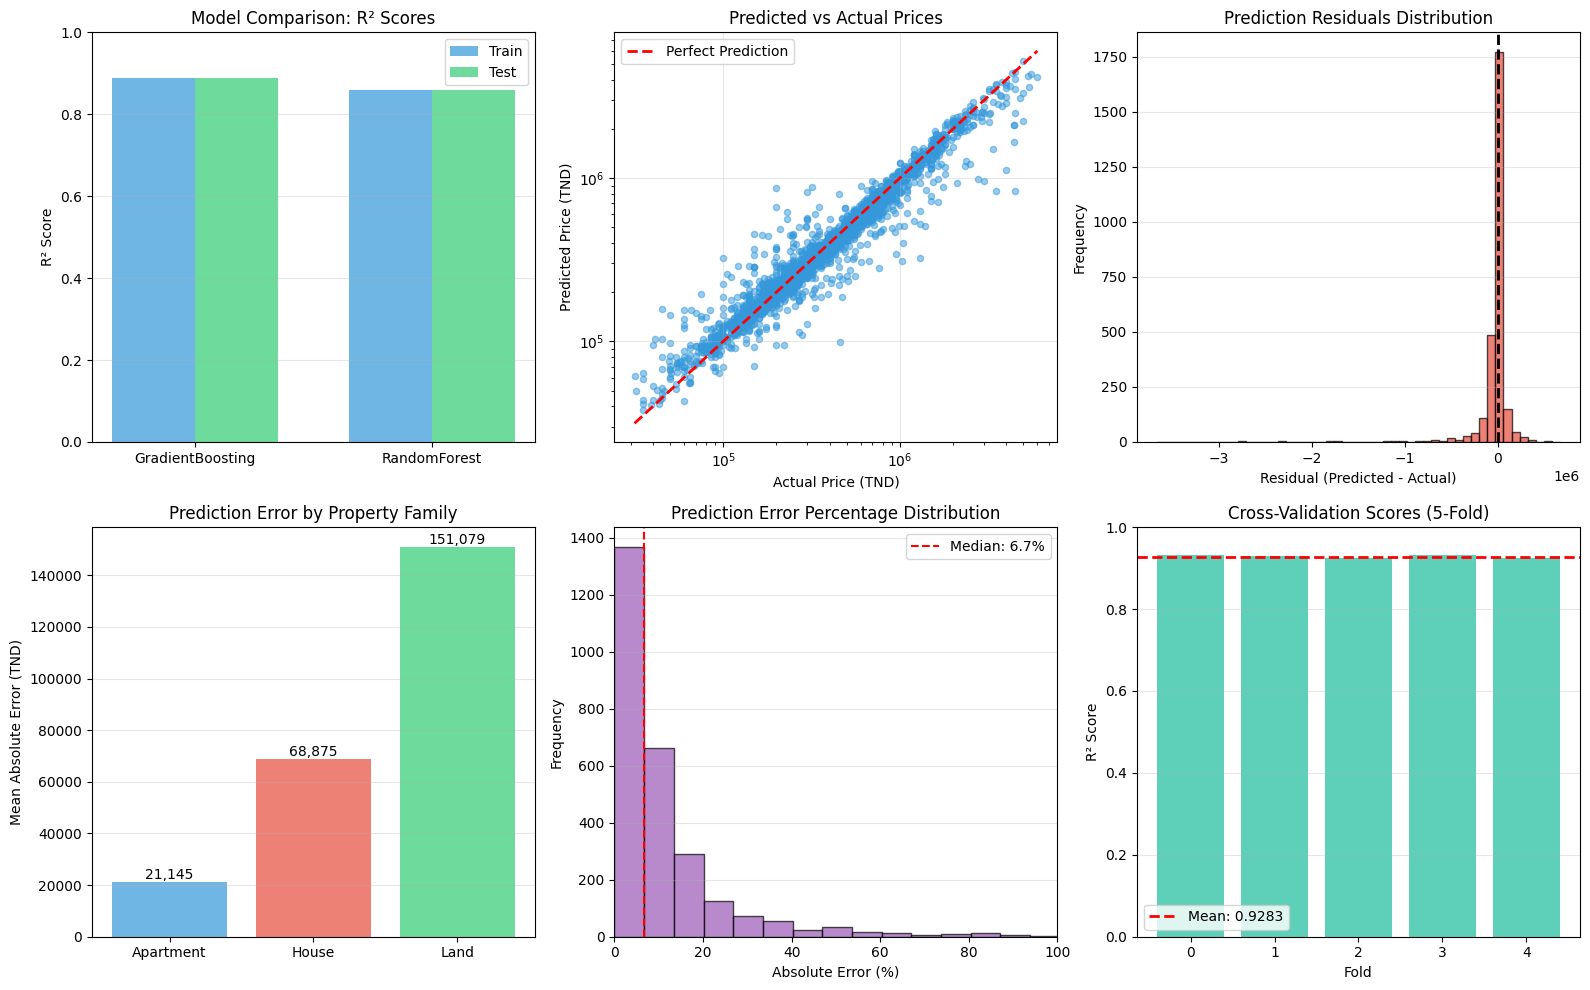

✓ Model performance visualizations complete


In [56]:
# Visualize model performance
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Model comparison
model_names = ['GradientBoosting', 'RandomForest']
train_scores = [gb_r2 if 'gb_r2' in dir() else 0, rf_r2 if 'rf_r2' in dir() else 0]
test_scores = [gb_r2, rf_r2]

x = range(len(model_names))
width = 0.35

axes[0, 0].bar([i - width/2 for i in x], train_scores, width, label='Train', color='#3498db', alpha=0.7)
axes[0, 0].bar([i + width/2 for i in x], test_scores, width, label='Test', color='#2ecc71', alpha=0.7)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(model_names)
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Model Comparison: R² Scores')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Predicted vs Actual
axes[0, 1].scatter(holdout['price_tnd'], holdout['predicted_price_tnd'], 
                  alpha=0.5, s=20, color='#3498db')
axes[0, 1].plot([holdout['price_tnd'].min(), holdout['price_tnd'].max()], 
               [holdout['price_tnd'].min(), holdout['price_tnd'].max()], 
               'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Price (TND)')
axes[0, 1].set_ylabel('Predicted Price (TND)')
axes[0, 1].set_title('Predicted vs Actual Prices')
axes[0, 1].legend()
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals distribution
residuals = holdout['predicted_price_tnd'] - holdout['price_tnd']
axes[0, 2].hist(residuals, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(0, color='black', linestyle='--', lw=2)
axes[0, 2].set_xlabel('Residual (Predicted - Actual)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Prediction Residuals Distribution')
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Error by property family
error_by_family = holdout.groupby('property_family')['error_tnd'].apply(lambda x: x.abs().mean())
axes[1, 0].bar(range(len(error_by_family)), error_by_family.values, 
              color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.7)
axes[1, 0].set_xticks(range(len(error_by_family)))
axes[1, 0].set_xticklabels([f.title() for f in error_by_family.index])
axes[1, 0].set_ylabel('Mean Absolute Error (TND)')
axes[1, 0].set_title('Prediction Error by Property Family')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(error_by_family.values):
    axes[1, 0].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

# 5. Error percentage distribution
axes[1, 1].hist(holdout['error_pct'].abs(), bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(holdout['error_pct'].abs().median(), color='red', linestyle='--', 
                  label=f'Median: {holdout["error_pct"].abs().median():.1f}%')
axes[1, 1].set_xlabel('Absolute Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Error Percentage Distribution')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 100)
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Cross-validation scores
if 'cv_scores' in dir():
    axes[1, 2].bar(range(len(cv_scores)), cv_scores, color='#1abc9c', alpha=0.7)
    axes[1, 2].axhline(cv_scores.mean(), color='red', linestyle='--', lw=2, 
                      label=f'Mean: {cv_scores.mean():.4f}')
    axes[1, 2].set_xlabel('Fold')
    axes[1, 2].set_ylabel('R² Score')
    axes[1, 2].set_title('Cross-Validation Scores (5-Fold)')
    axes[1, 2].legend()
    axes[1, 2].set_ylim([0, 1])
    axes[1, 2].grid(axis='y', alpha=0.3)
else:
    axes[1, 2].text(0.5, 0.5, 'CV scores not available', 
                   ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Cross-Validation Scores')

plt.tight_layout()
plt.show()

print("✓ Model performance visualizations complete")


In [57]:
# Final summary
print("=" * 60)
print("PIPELINE EXECUTION COMPLETE")
print("=" * 60)
print(f"\nTraining dataset: {frontend_summary['training_rows']:,} rows")
print(f"Modeling subset: {frontend_summary['modeling_rows']:,} rows")
print(f"Best model: {frontend_summary['best_model']}")
print(f"Validation R²: {frontend_summary['validation_r2']:.4f}")
print(f"Direct delegations: {frontend_summary['delegations_with_direct_support']} / {frontend_summary['total_delegations']}")
print(f"\nAll artifacts saved to:")
for label, path in manifest["core_assets"].items():
    print(f"  - {label}: {path}")
print("\n✓ Pipeline notebook execution complete!")


PIPELINE EXECUTION COMPLETE

Training dataset: 13,788 rows
Modeling subset: 13,651 rows
Best model: GradientBoosting
Validation R²: 0.8897
Direct delegations: 103 / 264

All artifacts saved to:
  - atlas_geojson: frontend\assets\data\atlas.geojson
  - zone_coverage: frontend\assets\data\zone_coverage.json
  - delegation_profiles: frontend\assets\data\delegation_profiles.json
  - model_summary: frontend\model_summary.json

✓ Pipeline notebook execution complete!
